<a href="https://colab.research.google.com/github/NAMU578/INFSUB/blob/main/notebooks/5_%EB%A7%B7%ED%94%8C%EB%A1%AF%EB%A6%BD%EB%AA%A8%EB%93%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 맷플롯립(matplotlib)
파이썬 그래프의 표준 라이브러리(1990년대 MATLAB 스타일에서 출발)<br>
[매트플롯라이브 공식사이트](https://matplotlib.org/)

In [ ]:
# 그래프를 작성할 때 matplotlib의 pyplot 모듈을 사용함
# plt라는 별명으로 불림 (pandas의 pd처럼 전 세계 공통 약속)
import matplotlib.pyplot as plt

## 그래프의 기본 구성

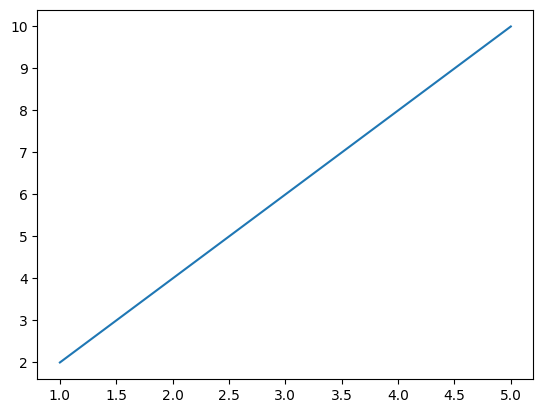

In [ ]:
# 간단한 그래프 작성하기
x = [1, 2, 3, 4, 5]  # ① 데이터 준비
y = [2, 4, 6, 8, 10]

plt.plot(x, y)       # ② 그래프 그리고
plt.show()           # ③ 화면에 표시

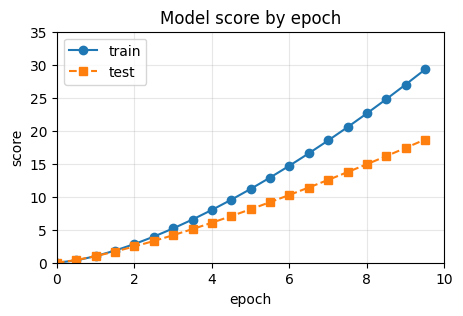

In [ ]:
import numpy as np

x = np.arange(0, 10, 0.5)          # 0부터 10 미만까지 0.5 간격

plt.figure(figsize=(5, 3))          # ① 도화지(figure) 크기: 가로 5, 세로 3인치

plt.plot(x, x**1.5, 'o-',  color='tab:blue',   label='train')   # ② 데이터와 스타일 지정
plt.plot(x, x**1.3, 's--', color='tab:orange', label='test')

plt.title('Model score by epoch')   # ③ 제목
plt.xlabel('epoch')                 # ④ x축 이름 (단위가 있다면 반드시 표시! 과학분야는 특히!)
plt.ylabel('score')                 # ⑤ y축 이름
plt.legend()                        # ⑥ 범례: label을 모두 지정해야 나타남
plt.grid(True, alpha=0.3)           # ⑦ 격자 (alpha=투명도)
plt.xlim(0, 10)                     # ⑧ x축 범위
plt.ylim(0, 35)                     # ⑨ y축 범위

plt.show()

# Matplotlib 마커와 선 스타일

## 마커 기호

- `'o'`: 원(circle)
- `'s'`: 사각형(square)
- `'^'`: 위쪽 삼각형(triangle_up)
- `'*'`: 별(star)

## 선 스타일

- `'-'`: 실선 (solid)
- `'--'`: 파선 / 대시 스타일 (dashed)
- `'-.'`: 일점쇄선 (dash-dot)
- `':'`: 점선 (dotted)

## 스타일 문자열 빠르게 익히기


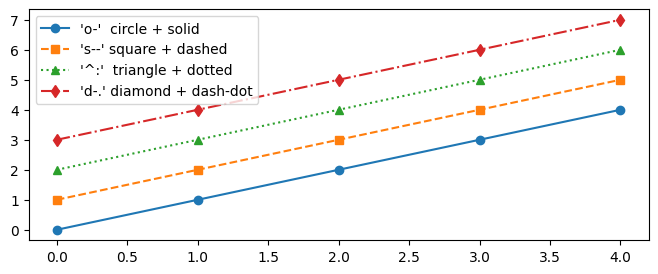

In [ ]:
# 'o-' 처럼 마커+선을 한 번에 지정할 수 있음
fig = plt.figure(figsize=(8, 3))
x = np.arange(5)   # 0~4 정수

plt.plot(x, x,     'o-',  label="'o-'  circle + solid")
plt.plot(x, x+1,   's--', label="'s--' square + dashed")
plt.plot(x, x+2,   '^:',  label="'^:'  triangle + dotted")
plt.plot(x, x+3,   'd-.', label="'d-.' diamond + dash-dot")
plt.legend(); plt.show()

# 색 지정 방법: color='red' / 'tab:blue' / '#2563eb' 3가지 모두 사용 가능

## 여러 그래프 한 화면에 표시하고 그래프 저장하기

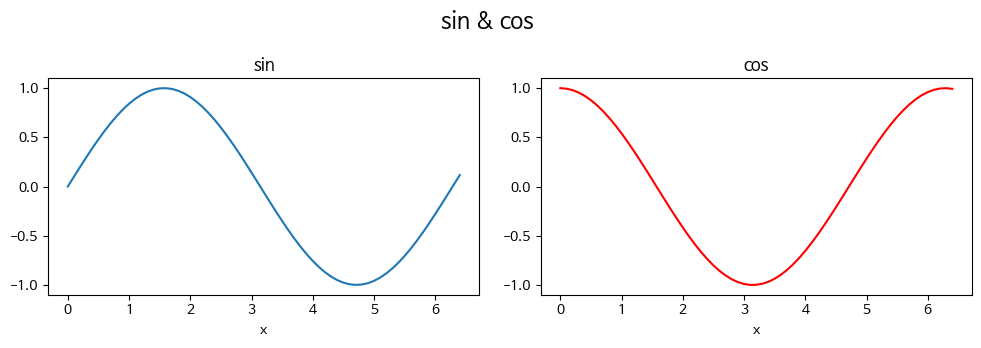

In [ ]:
import numpy as np
x = np.arange(0, 6.5, 0.1)

# 1행 2열 그래프 그리기
# fig(액자 역할, 전체크기, 저장, 대제목 등)
# axes(액자 속 각각의 사진, 각 칸의 그래프, 제목, 축 등 )
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5)) # 1행 2열 가로 10 세로 3.5

fig.suptitle('sin & cos', fontsize=16) # 대제목 표시, 글자 크기를 16으로 설정

axes[0].plot(x, np.sin(x))          # 왼쪽 그래프
axes[0].set_title('sin')            # ★ 주의: plt.title()이 아니라 ax.set_title()
axes[0].set_xlabel('x')

axes[1].plot(x, np.cos(x), color='red')   # 오른쪽 그래프
axes[1].set_title('cos')
axes[1].set_xlabel('x')

plt.tight_layout()    # 겹침 자동 정리

plt.savefig('result1.png') # 결과를 그림으로 저장 (show() 전에 호출해야 함)
plt.show()

fig.savefig('result2.png')  # 결과를 그림으로 저장 (fig를 통해 저장할 때는 여기서도 가능)

## AI 연구 시 사용하는 대표적인 그래프


In [ ]:
# 실습을 위한 데이터 가져오기
import seaborn as sns   # 여기서는 데이터 로딩용으로만 사용

titanic = sns.load_dataset('titanic')[['survived','pclass','sex','age','fare']]
print(titanic.head())

print('-'*50)  # 구분선

iris = sns.load_dataset('iris')
print(iris.sample(5))

   survived  pclass     sex   age     fare
0         0       3    male  22.0   7.2500
1         1       1  female  38.0  71.2833
2         1       3  female  26.0   7.9250
3         1       1  female  35.0  53.1000
4         0       3    male  35.0   8.0500
--------------------------------------------------
     sepal_length  sepal_width  petal_length  petal_width     species
94            5.6          2.7           4.2          1.3  versicolor
13            4.3          3.0           1.1          0.1      setosa
146           6.3          2.5           5.0          1.9   virginica
68            6.2          2.2           4.5          1.5  versicolor
111           6.4          2.7           5.3          1.9   virginica


### 1)히스토그램: 분포 확인
히스토그램은<br>
① 데이터의 최솟값~최댓값 범위를 같은 폭의 구간(bin)으로 나누고<br>
② 각 구간에 들어가는 데이터 개수를 세서 <br>
③ 막대 높이로 표시

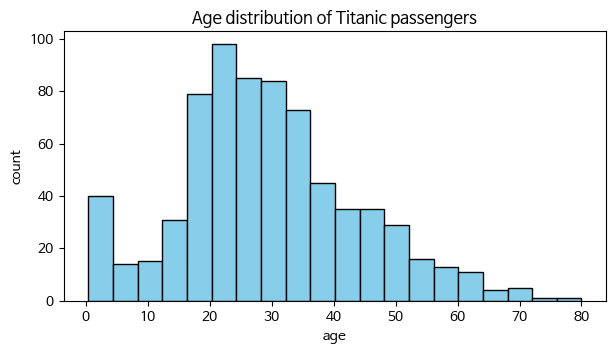

In [ ]:
# 용도: 데이터가 어디에 몰려 있나? 치우쳤나? 이상한 값이 있나?
plt.figure(figsize=(7, 3.5))

# titanic['age']에는 결측치가 있기 때문에 결측치는 빼고(dropna()) 그래프 표시(원본은 변동없음)
# bins=20 최소값~최대값 구간을 20개로 균등 구간으로 나눔
plt.hist(titanic['age'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Age distribution of Titanic passengers')
plt.xlabel('age'); plt.ylabel('count')
plt.show()

# bins(구간 수)를 5, 20, 40으로 3가지로 표시해 본다면?
# titanic['fare'] 시리즈에 대해 히스토그램 그래프 그려보자

In [ ]:
#자유롭게 작성

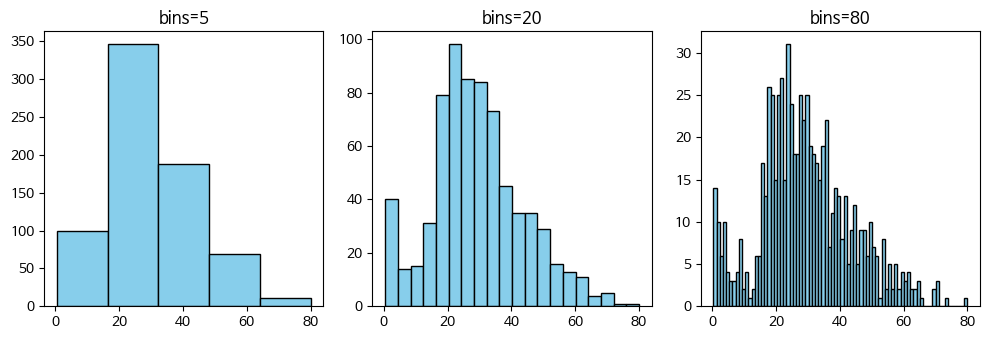

In [ ]:
# bins 에 따라 데이터가 어떻게 보이는지 비교해 보자
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, b in zip(axes, [5, 20, 80]):
    ax.hist(titanic['age'].dropna(), bins=b, color='skyblue', edgecolor='black')
    ax.set_title(f'bins={b}')
plt.tight_layout(); plt.show()

### 2)산점도 그래프: 두 특성(시리즈) 관계

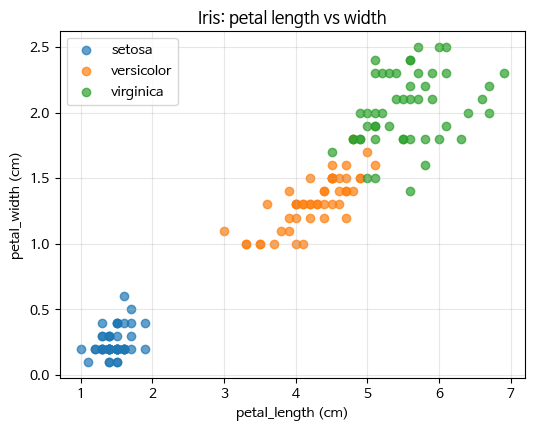

In [ ]:
# 용도: 특성 2개로 클래스가 나뉘는지 확인 → 모델 선택의 근거로 자주 활용
plt.figure(figsize=(6, 4.5))

for species, color in zip(['setosa','versicolor','virginica'],
                          ['tab:blue','tab:orange','tab:green']):
    part = iris[iris['species'] == species]          # 불리언 인덱싱 복습!
    plt.scatter(part['petal_length'], part['petal_width'],
                color=color, label=species, alpha=0.7)

plt.title('Iris: petal length vs width')
plt.xlabel('petal_length (cm)')
plt.ylabel('petal_width (cm)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### 3)막대그래프
AI 연구 시 그룹간 비교할 때 많이 사용<br>
그룹간 비교할 때 groupby 함께 사용


pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


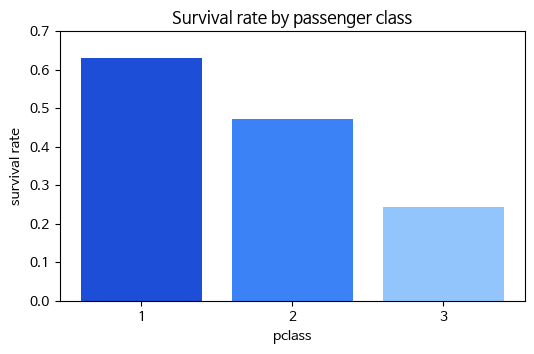

In [ ]:
# 용도: 범주(그룹)별 수치 비교
surv = titanic.groupby('pclass')['survived'].mean()
print(surv)

plt.figure(figsize=(6, 3.5))
plt.bar(surv.index.astype(str), surv.values, color=['#1d4ed8','#3b82f6','#93c5fd'])
plt.title('Survival rate by passenger class')
plt.xlabel('pclass'); plt.ylabel('survival rate')
plt.ylim(0, 0.7)
plt.show()

# 가로 막대는 plt.barh() — 항목 이름이 길 때(특성 중요도 등) 유용


### 4)박스플롯: 분포 비교 + 이상치 탐지


( 3 , 50 )


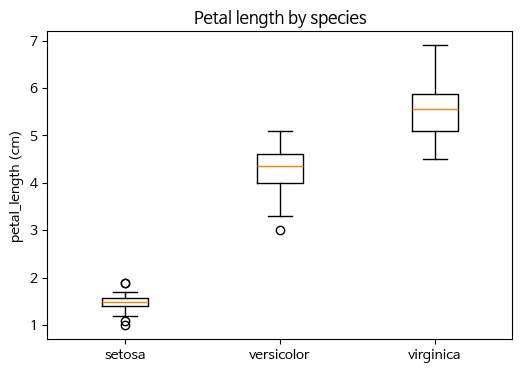

In [27]:
pl_by_species = [iris[iris['species'] == s]['petal_length']
                 for s in iris['species'].unique()]
# print(pl_by_species)
# pl_by_species는 리스트 컴프리핸션으로 만든 2차원 파이썬 리스트
# pl_by_species.shape 사용 못함.
print("(",len(pl_by_species),",",len(pl_by_species[0]),")")# 헷갈릴 수 있으나, (함수,함수) 꼴을 출력하기 위해 소괄호와 콤마를 따옴표로 감싼것임.

plt.figure(figsize=(6, 4))
plt.boxplot(pl_by_species, tick_labels=iris['species'].unique())
plt.title('Petal length by species')
plt.ylabel('petal_length (cm)')
plt.show()

# 읽는 법: 상자 = 가운데 50% 데이터, 중앙선 = 중앙값, 동그라미 = 이상치 후보
# ※ matplotlib 3.9 미만 구버전에서는 tick_labels 대신 labels를 사용

### 5)선그래프: 변화 추이
AI에서는 학습 곡선 표시할 때 많이 사용

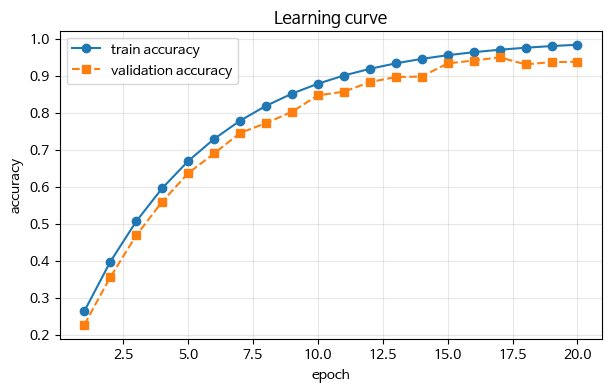

In [ ]:
# 임의로 만든 예시 데이터
epochs = np.arange(1, 21)
train_acc = 1 - 0.9 * np.exp(-epochs / 5)
val_acc   = train_acc - 0.02 - 0.03 * np.random.RandomState(0).rand(20)

plt.figure(figsize=(7, 4))

# x축:epochs, y축: train accuracy
plt.plot(epochs, train_acc, 'o-',  label='train accuracy')

# x축:epochs, y축: validation accuracy
plt.plot(epochs, val_acc,   's--', label='validation accuracy')

plt.title('Learning curve')
plt.xlabel('epoch'); plt.ylabel('accuracy')
plt.legend(); plt.grid(True, alpha=0.3)

plt.show()

### 6)히트맵: 특성 간 상관관계 표시
단, 수치형 자료에 대해서만 상관관계 계산 가능함.

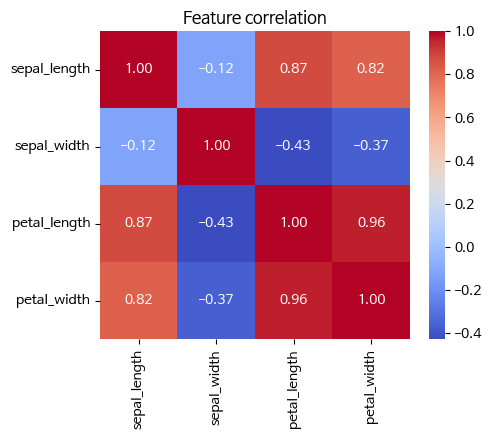

In [31]:
# 3.데이터이해(예제).ipynb 파일에 있는 히트맵과 비슷

plt.figure(figsize=(5, 4))
# sns.heatmap(iris.drop(columns='species').corr(), annot=True, cmap='Blues', fmt='.2f')
sns.heatmap(iris.drop(columns='species').corr(), annot=True, fmt='.2f', cmap='coolwarm')
# sns.heatmap(iris.drop(columns='species').corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Feature correlation'); plt.show()